<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab7/L7_Colab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7.1 Database & Visulization 2 - Exploring Grafana Dashboard

## Learning Goals

Students will be able to:

1. Extract information from a database using the Grafana Dashboard
2. Discuss the relationship between the MTConnect agent and Grafana
3. Create visualizations in the Grafana Dashboard by combining Grafana features and SQL statements
4. Build a monitoring system in Grafana that connects all of the sensors, MTConnect Adapaters, Agents, SQL database, and Grafana dashboard features.


## 1.1 Introduction

The topic of Lab7 is visualization using Grafana web dashboard. We will practice creating Grafana dashboard using the existing database first and then build up the entire system yourself to monitor sensor data using Grafana in real-time remotely. At the end of this lab, you will be able to create the entire real-time remote IIoT monitoring system from the sensors or IoT devices to a web-based dashboard.


## 1.2 Log-in Grafana web server

Let’s start with log in the Grafana server. The Grafana server domain and the port number information for this lab are as follows.
* DNS: mepotrb16.ecn.purdue.edu
* Port: 3000
  * Please note that default port number of Grafana is 3000.
* Grafana web page URL: http://mepotrb16.ecn.purdue.edu:3000/

When you access the Grafana web page using a web browser on your laptop, you will see the log-in page as Figure 1. TA already made an account for you. The username is the same as the MySQL account name, i.e., your username for Grafana is ‘firstnamelastname’ based on Brightspace, e.g., John Doe’s username for ME597 Grafana server is ‘johndoe’. Or you can use your **Purdue email address** as the log-in information. And TA will let you know the password of your account.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab7_fig1.png?raw=true" width="100%">

*Figure 1 Log-in page of Grafana server*

After successfully logging on to the Grafana server, you will see the main page as Figure 2. When you put the mouse pointer on the profile icon, and then you will see the profile menu. If you want to change password or information of your account, try it.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab7_fig2.png?raw=true" width="100%">

*Figure 2 Grafana main page*

## 1.3 Access To Dashboard

Before accessing the dashboard, let’s understand the system and the data first. The schematic of the example system for the dashboards is shown in Figure 4. This is important because you should create the same system by accessing the data from sensors at the end of this lab. As we performed in Lab4,
MTConnect adapter simulator is being used in this part. The target sensors are 1) DS18B20 & Virtual sensor, 2) ADXL345, and 3) power meter. The example data are shown in Figure 3. These example data for approximately 3 minutes are repeating continuously and infinitely in the MTConnect adapter simulator. All simulated data is transmitted to MTConnect agent.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S25_update/lab7_fig3.png?raw=true" width="100%">

*Figure 3 Example data for the example dashboard*

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S25_update/lab7_fig4.png?raw=true" width="80%">

*Figure 4 Schematic of example system*

The information about the system is summarized as follows.
* MTConnect agent: http://mepotrb16.ecn.purdue.edu:5000/
* MySQL server DNS (same as Lab6): mepotrb16.ecn.purdue.edu
  * Port: 3306
  * Database: *

*   List item
*   List item


  * Table: grafana_sample
  * Table schema is the same as Lab6. But the only difference is the precision of the TIMESTAMP column. This is explained in the later section.
* Sensor
  * DS18B20
    * Temperature (Sample) in °C unit
  * Virtual sensor
    * Humidity (Sample) in %RH unit
  * ADXL345
    * X-axis acceleration (Sample) in m/s2 unit
    * Y-axis acceleration (Sample) in m/s2 unit
    * Z-axis acceleration (Sample) in m/s2 unit
  * Power meter
    * True power (Sample) of vacuum pump in Watt unit
    * Power state (Event): ‘ON’ or ‘OFF’
      * When the true power is larger than 30 W, the result is ‘ON’ which means the vacuum pump is running.

If you request current information to MTConnect agent, you will see the result as Figure 5 (This window is captured on the server PC. You don't need to do this on your PC.). By aggregating MTConnect agent data, the MySQL database (‘grafana_sample’ table) is updated continuously. **If nothing is shown in your browser, please close the "Pretty" style following the instruction of Task 2.1 in [L4 Colab 2](https://githubtocolab.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab4/L4_Colab2.ipynb).**

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S25_update/lab7_fig5.png?raw=true" width="70%">


*Figure 5 Capture of current response from MTConnect agent*

If you check the data in ‘grafana_sample’ table using SELECT statement as below on MySQL Workbench, you will see the result grid as Figure 6. Try this on MySQL Workbench yourself. If you compare the MTConnect agent data and MySQL database, you can confirm that all data in the MTConnect are aggregated into the database in real-time.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_SQL.png?raw=tru" width="40">SQL - SELECT statement to see the table in descending order by timestamp**

```
SELECT * FROM ME597Spring26.grafana_sample
ORDER BY timestamp ASC
```

---

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S25_update/lab7_fig6.png?raw=true" width="70%">

*Figure 6 Result grid of grafana_sample table*

### Task 1.1

Capture your web browser after requesting ‘current’ information to the MTConnect agent as Figure 5 and attach it below.

---

Place your screenshot here.
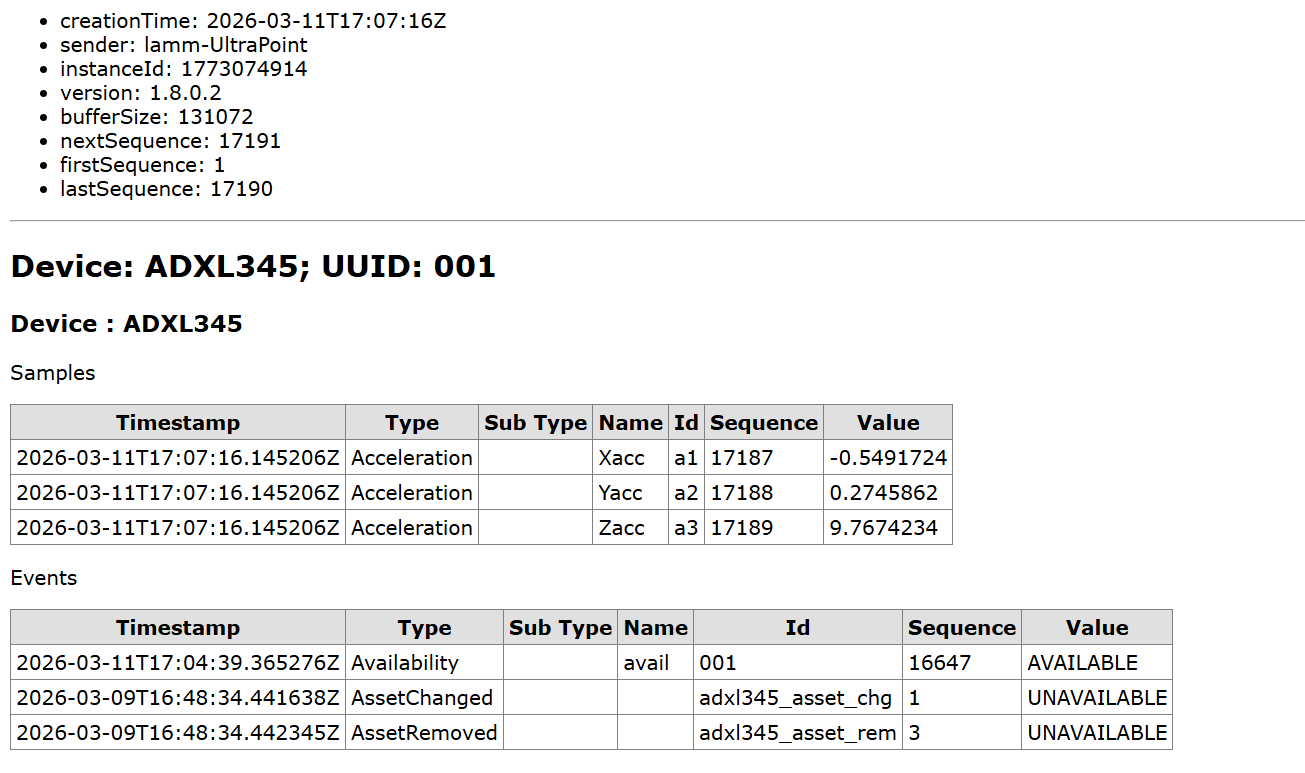
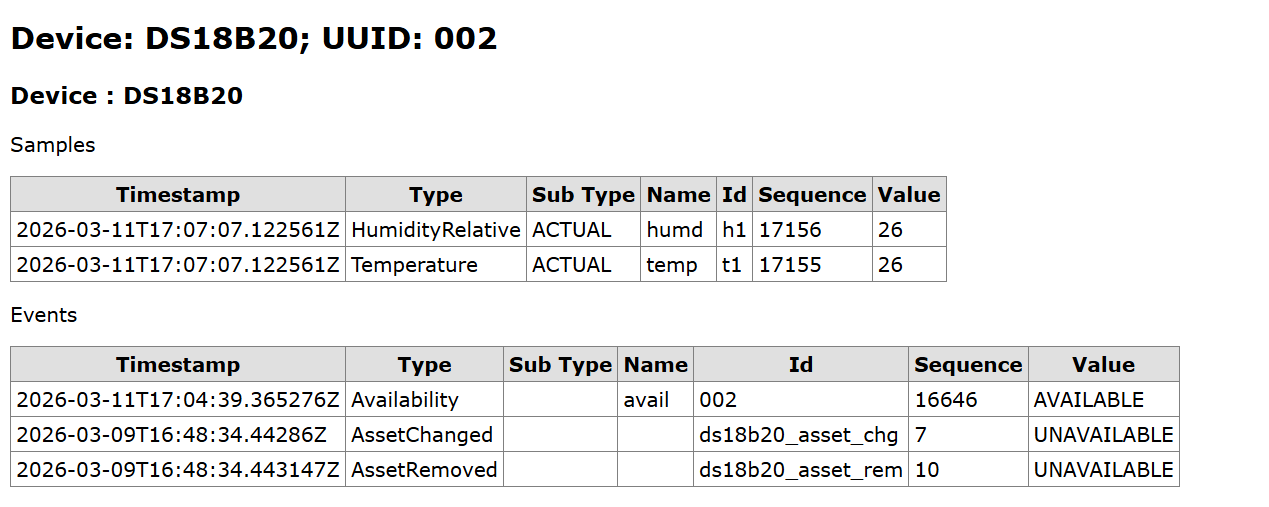
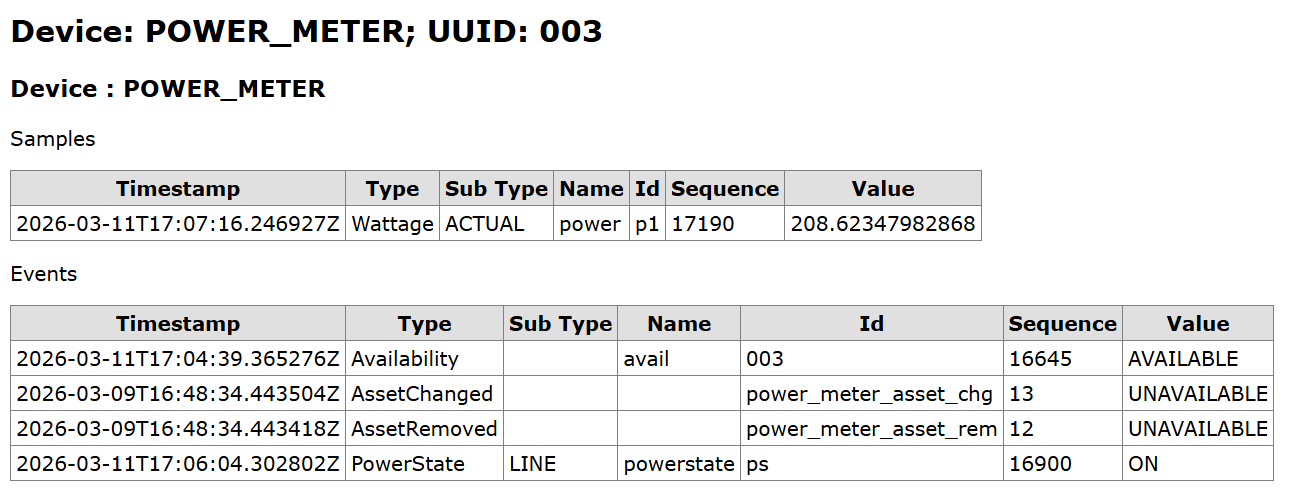
---



### Task 1.2

1.	Capture your result grid as Figure 6 after querying the SELECT statement above to ‘grafana_sample’ table and attach it to the report.

  ---

  Place your screenshot here.
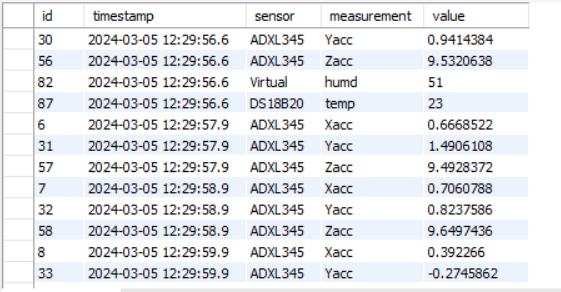
  ---



2. Answer the questions below by comparing the MTConnect agent and the MysQL database table.

In [ ]:

#@markdown #### What information in MTConnect agent is stored in the 'timestamp' column? {display-mode: "form"}
T2_1 = 'The time at which the data was captured ' #@param {type:"string"}
print(T2_1)

#@markdown #### What information in MTConnect agent is stored in the 'sensor' column? {display-mode: "form"}
T2_2 = 'The sensor used to capture the data' #@param {type:"string"}
print(T2_2)

#@markdown #### What information in MTConnect agent is stored in the 'measurement' column? {display-mode: "form"}
T2_3 = 'The parameter that is being captured. e.g. humidity, temperature, Xacc etc..' #@param {type:"string"}
print(T2_3)

#@markdown #### What information in MTConnect agent is stored in the 'value' column? {display-mode: "form"}
T2_4 = 'The value of the parameter being captured' #@param {type:"string"}
print(T2_4)



Let’s go back to the Grafana webpage to see the example dashboard. To see the example dashboard (‘Lab7 dashboard example’) page, follow the steps below.

1.	Click ‘Browse’ on the ‘Dashboards’ dropdown menu

  a. You can see the dropdown menu when you put your mouse pointer on the ‘Dashboards’ icon on the ‘side menu bar’.
2.	Click ‘Lab7’ folder
3.	Click ‘Lab7 dashboard example’

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab7_img1.png?raw=true" width="60%">

  
You will see the example dashboard webpage as Figure 7. The brief description of each data visualization is as follows.
  
<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab7_fig7.png?raw=true" width="100%">

*Figure 7 Grafana Lab7 dashboard example*

  a.	ADXL345 data (Sample) as Table

  b.	Power data (Sample) as Time series

  c.	Power state data (Event) as Discrete

  d.	DHT11 temperature data (Sample) as Time series

  e.	DHT11 humidity data (Sample) as Time series

  f.	ADXL345 data (Sample) as Time series

As you can see, the default time range of the dashboard is set as last 1 hour. To change the time range, click the time range icon on the right side of the top menu bar and then you will see the time range menu as Figure 8. If you click Last 5 minutes, the time range is changed from the last 5 minutes to now as Figure 9. Also, if you click the refresh icon, you will see the updated dashboard in real time.
  
  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab7_fig8.png?raw=true" width="50%">

*Figure 8 Time range menu of Grafana dashboard*
  
  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab7_fig9.png?raw=true" width="100%">

*Figure 9 Grafana Lab7 dashboard example after changing the time range to Last 5 minutes*

If you want to see a graph or table in detail, click ‘View’ on the menu on the title of a graph as Figure 10. The example of DHT11 Temperature graph is shown in Figure 11. To go back to the dashboard page, click 'Go back' icon (a back arrow) or hit 'Esc' on your keyboard.

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab7_fig10.png?raw=true" width="70%">

*Figure 10 View to see a graph in detail*

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab7_fig11.png?raw=true" width="70%">

*Figure 11 Detail view of DHT11 Temperature graph.*



## 1.4 Create Folder and Dashboard

Now, let’s create sample dashboards to practice Grafana and SQL query. To create your dashboard page, follow the steps below. Please note that the data source (MySQL database) setup was done by TA.

1.	Go back to the ‘Dashboards’ page by clicking on ‘Browse’.
2.	Create your folder by clicking on ‘New Folder’

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab7_img2.png?raw=true" width="90%">

  
3.	Make the folder name as **your name** in the form of ‘Firstname Lastname’, e.g., John Doe, and then click ‘Create’

  a. You will work in this folder for the following activities.

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab7_img3.png?raw=true" width="70%">


  
4.	Click ‘Create Dashboard’

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab7_img4.png?raw=true" width="90%">
  
You will see the ‘New dashboard’ as Figure 12. Now, you are ready to create panels. Save the created dashboard as ‘Practice’ as Figure 13 by clicking the ‘Save dashboard’ icon on the right side of the top menu bar. Please be make sure that the Folder should be the folder you created.
  
  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab7_fig12.png?raw=true" width="90%">

*Figure 12 Grafana new dashboard*

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab7_fig13.png?raw=true" width="60%">


*Figure 13 Save dashboard*


<br></br>

Please continue to [Lab 7.2 here](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab7/L7_Colab2.ipynb).

